In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load the dataset
df = pd.read_csv("matches.csv")

# Display the first 5 rows
df.head()

,round,gameweek,dayofweek,date,start_time,home_team,away_team,score,home_score,away_score,...,away_fouls,home_corners,away_corners,home_crosses,away_crosses,home_interceptions,away_interceptions,home_offsides,away_offsides,notes
0,Group stage,1.0,Thu,11/06/2026,13:00,Mexico,South Africa,2–0,2,0,...,11,3,1,12,8,8,7,1.0,1.0,NaN
1,Group stage,1.0,Thu,11/06/2026,20:00,Korea Republic,Czechia,2–1,2,1,...,16,4,5,12,15,11,7,2.0,2.0,NaN
2,Group stage,1.0,Fri,12/06/2026,15:00,Canada,Bosnia–Herz,1–1,1,1,...,20,9,4,24,10,4,10,1.0,0.0,NaN
3,Group stage,1.0,Fri,12/06/2026,18:00,United States,Paraguay,4–1,4,1,...,17,3,1,17,5,11,9,2.0,1.0,NaN
4,Group stage,1.0,Sat,13/06/2026,12:00,Qatar,Switzerland,1–1,1,1,...,11,3,10,8,35,10,7,0.0,1.0,NaN


In [3]:
# Number of rows and columns
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Display column names
print(df.columns.tolist())

Rows: 104
Columns: 42
['round', 'gameweek', 'dayofweek', 'date', 'start_time', 'home_team', 'away_team', 'score', 'home_score', 'away_score', 'attendance', 'venue', 'referee', 'home_formation', 'away_formation', 'home_manager', 'away_manager', 'home_captain', 'away_captain', 'home_possession', 'away_possession', 'home_sot', 'away_sot', 'home_total_shots', 'away_total_shots', 'home_saves', 'away_saves', 'home_cards_yellow', 'away_cards_yellow', 'home_cards_red', 'away_cards_red', 'home_fouls', 'away_fouls', 'home_corners', 'away_corners', 'home_crosses', 'away_crosses', 'home_interceptions', 'away_interceptions', 'home_offsides', 'away_offsides', 'notes']


In [4]:
# Select the columns needed for this analysis
matches = df[
    [
        "round",
        "date",
        "home_team",
        "away_team",
        "home_score",
        "away_score"
    ]
].copy()

matches.head()

,round,date,home_team,away_team,home_score,away_score
0,Group stage,11/06/2026,Mexico,South Africa,2,0
1,Group stage,11/06/2026,Korea Republic,Czechia,2,1
2,Group stage,12/06/2026,Canada,Bosnia–Herz,1,1
3,Group stage,12/06/2026,United States,Paraguay,4,1
4,Group stage,13/06/2026,Qatar,Switzerland,1,1


In [5]:
# Check missing values
matches.isnull().sum()

round         0
date          0
home_team     0
away_team     0
home_score    0
away_score    0
dtype: int64

In [6]:
# Correct the four missing scores in the dataset
score_corrections = {
    "Germany vs Paraguay": (1, 1),
    "Netherlands vs Morocco": (1, 1),
    "Australia vs Egypt": (1, 1),
    "Switzerland vs Colombia": (0, 0)
}

for index, row in matches.iterrows():
    match_name = f"{row['home_team']} vs {row['away_team']}"
    
    if match_name in score_corrections:
        matches.loc[index, "home_score"] = score_corrections[match_name][0]
        matches.loc[index, "away_score"] = score_corrections[match_name][1]

matches.isnull().sum()

round         0
date          0
home_team     0
away_team     0
home_score    0
away_score    0
dtype: int64

In [7]:
# Calculate absolute goal difference
matches["goal_difference"] = (
    matches["home_score"] - matches["away_score"]
).abs()

matches.head()

,round,date,home_team,away_team,home_score,away_score,goal_difference
0,Group stage,11/06/2026,Mexico,South Africa,2,0,2
1,Group stage,11/06/2026,Korea Republic,Czechia,2,1,1
2,Group stage,12/06/2026,Canada,Bosnia–Herz,1,1,0
3,Group stage,12/06/2026,United States,Paraguay,4,1,3
4,Group stage,13/06/2026,Qatar,Switzerland,1,1,0


In [8]:
# Display all round categories
print(matches["round"].value_counts())

round
Group stage          72
Round of 32          16
Round of 16           8
Quarter-finals        4
Semi-finals           2
Third-place match     1
Final                 1
Name: count, dtype: int64


In [9]:
# Classify matches into Group Stage or Knockout Stage

matches["stage"] = np.where(
    matches["round"].str.contains(
        "Group", 
        case=False, 
        na=False
    ),
    "Group Stage",
    "Knockout Stage"
)

matches["stage"].value_counts()

stage
Group Stage       72
Knockout Stage    32
Name: count, dtype: int64

In [10]:
matches[
    [
        "round",
        "stage",
        "home_team",
        "away_team",
        "home_score",
        "away_score",
        "goal_difference"
    ]
].head(20)

,round,stage,home_team,away_team,home_score,away_score,goal_difference
0,Group stage,Group Stage,Mexico,South Africa,2,0,2
1,Group stage,Group Stage,Korea Republic,Czechia,2,1,1
2,Group stage,Group Stage,Canada,Bosnia–Herz,1,1,0
3,Group stage,Group Stage,United States,Paraguay,4,1,3
4,Group stage,Group Stage,Qatar,Switzerland,1,1,0
5,Group stage,Group Stage,Brazil,Morocco,1,1,0
6,Group stage,Group Stage,Australia,Türkiye,2,0,2
7,Group stage,Group Stage,Haiti,Scotland,0,1,1
8,Group stage,Group Stage,Germany,Curaçao,7,1,6
9,Group stage,Group Stage,Netherlands,Japan,2,2,0


In [11]:
print("Total matches:", len(matches))
print("Missing scores:", matches[["home_score", "away_score"]].isnull().sum().sum())
print("Missing goal differences:", matches["goal_difference"].isnull().sum())

Total matches: 104
Missing scores: 0
Missing goal differences: 0


In [12]:
# Take a random sample of 40 matches
sample = matches.sample(
    n=40,
    random_state=42
)

print("Sample size:", len(sample))

Sample size: 40


In [13]:
sample[
    [
        "round",
        "stage",
        "home_team",
        "away_team",
        "home_score",
        "away_score",
        "goal_difference"
    ]
].head(10)

,round,stage,home_team,away_team,home_score,away_score,goal_difference
30,Group stage,Group Stage,Türkiye,Paraguay,0,1,1
65,Group stage,Group Stage,New Zealand,Belgium,1,5,4
64,Group stage,Group Stage,Egypt,IR Iran,1,1,0
53,Group stage,Group Stage,Czechia,Mexico,0,3,3
45,Group stage,Group Stage,England,Ghana,0,0,0
93,Round of 16,Knockout Stage,United States,Belgium,1,4,3
91,Round of 16,Knockout Stage,Mexico,England,2,3,1
47,Group stage,Group Stage,Colombia,Congo DR,1,0,1
10,Group stage,Group Stage,Côte d'Ivoire,Ecuador,1,0,1
0,Group stage,Group Stage,Mexico,South Africa,2,0,2


In [14]:
# Overall descriptive statistics for the sample
sample["goal_difference"].describe()

count    40.0000
mean      1.6000
std       1.4641
min       0.0000
25%       1.0000
50%       1.0000
75%       2.2500
max       6.0000
Name: goal_difference, dtype: float64

In [15]:
stage_summary = sample.groupby("stage")["goal_difference"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

stage_summary

,count,mean,median,std,min,max
stage,,,,,,
Group Stage,27,1.703704,1.0,1.636479,0,6
Knockout Stage,13,1.384615,1.0,1.043908,0,3


In [16]:
group_stage = sample[
    sample["stage"] == "Group Stage"
]["goal_difference"]

print("Group-stage matches:", len(group_stage))
print("Mean goal difference:", group_stage.mean())
print("Median:", group_stage.median())
print("Standard deviation:", group_stage.std())

Group-stage matches: 27
Mean goal difference: 1.7037037037037037
Median: 1.0
Standard deviation: 1.6364787435413506


In [17]:
knockout_stage = sample[
    sample["stage"] == "Knockout Stage"
]["goal_difference"]

print("Knockout-stage matches:", len(knockout_stage))
print("Mean goal difference:", knockout_stage.mean())
print("Median:", knockout_stage.median())
print("Standard deviation:", knockout_stage.std())

Knockout-stage matches: 13
Mean goal difference: 1.3846153846153846
Median: 1.0
Standard deviation: 1.0439078454267836


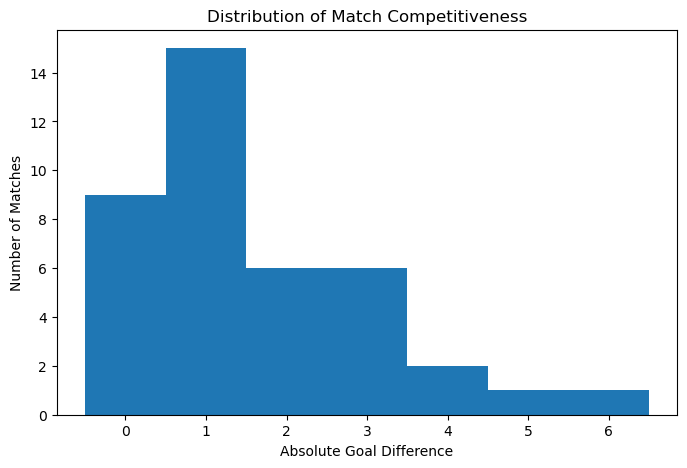

In [18]:
plt.figure(figsize=(8, 5))

plt.hist(
    sample["goal_difference"],
    bins=np.arange(
        sample["goal_difference"].min() - 0.5,
        sample["goal_difference"].max() + 1.5,
        1
    )
)

plt.xlabel("Absolute Goal Difference")
plt.ylabel("Number of Matches")
plt.title("Distribution of Match Competitiveness")
plt.xticks(range(int(sample["goal_difference"].max()) + 1))
plt.show()

<Figure size 800x500 with 0 Axes>

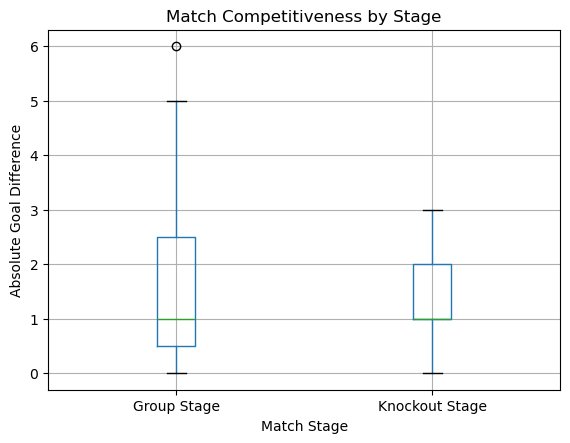

In [19]:
plt.figure(figsize=(8, 5))

sample.boxplot(
    column="goal_difference",
    by="stage"
)

plt.xlabel("Match Stage")
plt.ylabel("Absolute Goal Difference")
plt.title("Match Competitiveness by Stage")
plt.suptitle("")

plt.show()

In [20]:
# Calculate 95% confidence interval for the sample mean
n = len(sample)
mean = sample["goal_difference"].mean()
std = sample["goal_difference"].std()

standard_error = std / np.sqrt(n)

confidence_interval = stats.t.interval(
    confidence=0.95,
    df=n - 1,
    loc=mean,
    scale=standard_error
)

print("Sample mean:", mean)
print("95% Confidence Interval:", confidence_interval)

Sample mean: 1.6
95% Confidence Interval: (np.float64(1.1317580018010018), np.float64(2.0682419981989986))


In [21]:
def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = data.mean()
    standard_error = stats.sem(data)
    
    return stats.t.interval(
        confidence=confidence,
        df=n - 1,
        loc=mean,
        scale=standard_error
    )

group_ci = confidence_interval(group_stage)
knockout_ci = confidence_interval(knockout_stage)

print("Group Stage 95% CI:", group_ci)
print("Knockout Stage 95% CI:", knockout_ci)

Group Stage 95% CI: (np.float64(1.05633427351475), np.float64(2.3510731338926574))
Knockout Stage 95% CI: (np.float64(0.7537881870991114), np.float64(2.0154425821316577))


In [22]:
# Welch's independent two-sample t-test
t_statistic, p_value = stats.ttest_ind(
    group_stage,
    knockout_stage,
    equal_var=False
)

print("t-statistic:", t_statistic)
print("p-value:", p_value)

t-statistic: 0.7458797642284192
p-value: 0.46075667477193294


In [23]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print(
        "There is statistically significant evidence "
        "that competitiveness differs between group-stage "
        "and knockout-stage matches."
    )
else:
    print("Fail to reject the null hypothesis.")
    print(
        "There is not enough statistical evidence "
        "to conclude that competitiveness differs between "
        "group-stage and knockout-stage matches."
    )

Fail to reject the null hypothesis.
There is not enough statistical evidence to conclude that competitiveness differs between group-stage and knockout-stage matches.


In [24]:
group_mean = group_stage.mean()
knockout_mean = knockout_stage.mean()

print(f"Group-stage mean absolute goal difference: {group_mean:.2f}")
print(f"Knockout-stage mean absolute goal difference: {knockout_mean:.2f}")
print(f"t-statistic: {t_statistic:.3f}")
print(f"p-value: {p_value:.3f}")

if knockout_mean < group_mean:
    print(
        "Knockout-stage matches had a smaller average goal difference, "
        "suggesting they were more competitive in the sample."
    )
else:
    print(
        "Group-stage matches had a smaller average goal difference, "
        "suggesting they were more competitive in the sample."
    )

Group-stage mean absolute goal difference: 1.70
Knockout-stage mean absolute goal difference: 1.38
t-statistic: 0.746
p-value: 0.461
Knockout-stage matches had a smaller average goal difference, suggesting they were more competitive in the sample.


In [25]:
sample["close_match"] = np.where(
    sample["goal_difference"] <= 1,
    "Close",
    "Not Close"
)

close_match_summary = pd.crosstab(
    sample["stage"],
    sample["close_match"]
)

close_match_summary

close_match,Close,Not Close
stage,,
Group Stage,15,12
Knockout Stage,9,4


In [26]:
close_match_percentage = (
    pd.crosstab(
        sample["stage"],
        sample["close_match"],
        normalize="index"
    ) * 100
)

close_match_percentage

close_match,Close,Not Close
stage,,
Group Stage,55.555556,44.444444
Knockout Stage,69.230769,30.769231


In [27]:
final_summary = sample.groupby("stage")["goal_difference"].agg(
    Matches="count",
    Mean="mean",
    Median="median",
    Standard_Deviation="std",
    Minimum="min",
    Maximum="max"
)

final_summary

,Matches,Mean,Median,Standard_Deviation,Minimum,Maximum
stage,,,,,,
Group Stage,27,1.703704,1.0,1.636479,0,6
Knockout Stage,13,1.384615,1.0,1.043908,0,3


In [28]:
print("RESEARCH QUESTION:")
print("Are FIFA World Cup 2026 knockout-stage matches more competitive than group-stage matches?\n")

print("MEASURE OF COMPETITIVENESS:")
print("Absolute goal difference. A smaller value indicates a more closely contested match.\n")

print(f"Group-stage mean goal difference: {group_mean:.2f}")
print(f"Knockout-stage mean goal difference: {knockout_mean:.2f}")
print(f"Welch t-test p-value: {p_value:.3f}\n")

if p_value < 0.05:
    print(
        "Conclusion: Reject H0. There is statistically significant evidence "
        "of a difference in competitiveness between the two stages."
    )
else:
    print(
        "Conclusion: Fail to reject H0. There is insufficient statistical "
        "evidence to conclude that competitiveness differs between "
        "group-stage and knockout-stage matches."
    )

RESEARCH QUESTION:
Are FIFA World Cup 2026 knockout-stage matches more competitive than group-stage matches?

MEASURE OF COMPETITIVENESS:
Absolute goal difference. A smaller value indicates a more closely contested match.

Group-stage mean goal difference: 1.70
Knockout-stage mean goal difference: 1.38
Welch t-test p-value: 0.461

Conclusion: Fail to reject H0. There is insufficient statistical evidence to conclude that competitiveness differs between group-stage and knockout-stage matches.
